# Running LAMMPS molecular dynamics with the ALIGNN-FF (`mps`) force field

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/knc6/jarvis-tools-notebooks/blob/master/jarvis-tools-notebooks/ALIGNN_FF_LAMMPS_Colab.ipynb)

This notebook is a self-contained, end-to-end walkthrough for driving **LAMMPS** molecular dynamics with the
**default ALIGNN-FF Materials-Project (`mps`) force field** through the native `pair_style alignn`.

Forces, energies and stresses come straight from the TorchScripted ALIGNN-FF model called by a C++ pair style
linked against libtorch — there is **no slow Python callback** in the MD loop.

**What you will do:**
1. Install ALIGNN.
2. Build LAMMPS with the `pair_alignn` style linked against libtorch (one-shot script).
3. Download the default ALIGNN-FF `mps` model and export it to TorchScript (`alignn_ff.pt`).
4. Build and relax a Si supercell.
5. Run an NVE energy-conservation test and plot the result.
6. (Optional) Run a melt–quench simulation to make amorphous Si.

> **Recommended runtime:** GPU. In Colab go to **Runtime → Change runtime type → Hardware accelerator → GPU**.
> The pair style auto-selects CUDA when available. CPU also works but MD is slower (~30 steps/s for 54 atoms).

> **Time budget:** the LAMMPS build step takes ~10–15 minutes. Everything after that is fast.

## 0. Check the runtime

Confirm whether a GPU is visible. This is informational — the build and run work on CPU too.

In [7]:
import torch
print('torch version :', torch.__version__)
print('torch CUDA    :', torch.version.cuda or 'cpu-only build')
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU           :', torch.cuda.get_device_name(0))
else:
    print('No GPU — MD will run on CPU (slower but fine for these examples).')

torch version : 2.11.0+cu128
torch CUDA    : 12.8
CUDA available: True
GPU           : Tesla T4


## 1. Install ALIGNN

We clone the repo (we need the `pair_alignn` C++ sources, the build script, and the example inputs) and
install it in editable mode.

In [8]:
%cd /content
# The LAMMPS examples currently live on the `develop` branch.
![ -d alignn ] || git clone --depth 1 -b develop https://github.com/atomgptlab/alignn.git
%cd /content/alignn
!pip install -q -e .
print('\nALIGNN installed (branch: develop).')

/content
/content/alignn
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for alignn (pyproject.toml) ... done

ALIGNN installed (branch: develop).


## 2. Build LAMMPS with `pair_alignn`

The one-shot script `build_lammps_alignn.sh`:
1. discovers the active PyTorch / CUDA / ABI,
2. clones LAMMPS (`stable_29Aug2024_update1`),
3. drops `pair_alignn.{cpp,h}` into LAMMPS `src/`,
4. links libtorch into the CMake build,
5. compiles, and
6. installs the `lammps` Python module + standalone `lmp` binary.

This is the slow step (**~10–15 min**). Output is trimmed; the final lines verify that `alignn` shows up as an
available pair style in both the Python module and the standalone binary.

In [9]:
# ~10-15 min. The script auto-detects GPU vs CPU and installs the CUDA/MKL
# build dependencies it needs (via pip on Colab).
!bash alignn/scripts/torch/build_lammps_alignn.sh

── paths ────────────────────────────────
script dir   : /content/alignn/alignn/scripts/torch
alignn repo  : /content/alignn
pair sources : /content/alignn/alignn/scripts/torch/pair_alignn
LAMMPS target: /root/lammps-alignn (tag stable_29Aug2024_update1)

── environment ──────────────────────────
python           = /usr/local/bin/python
torch            = 2.11.0+cu128
torch CUDA       = 12.8
torch CXX11 ABI  = 1
cmake            = cmake version 3.31.10
prefix           = /usr
has mamba        = 0

[1/5] LAMMPS dir exists at /root/lammps-alignn, reusing
[2/5] installing pair_alignn.{cpp,h} into LAMMPS src/...
  libtorch hook already present
[3/5] cmake configure...
    runtime library [libgomp.so.1] in /usr/lib/gcc/x86_64-linux-gnu/11 may be hidden by files in:
      /usr/local/lib/python3.12/dist-packages/torch/lib

  Some of these libraries may not be found correctly.


-- Generating done (0.1s)
-- Build files have been written to: /root/lammps-alignn/build

[4/5] compiling (this take

## NOTE: RESTART SESSION HERE

In [5]:
# Sanity check: the standalone lmp binary and Python module both know pair_alignn.
import os
LMP = os.path.expanduser('~/lammps-alignn/build/lmp')
print('lmp binary:', LMP, '— exists:', os.path.exists(LMP))

from lammps import lammps
_l = lammps()
print("'alignn' in available pair styles:", 'alignn' in _l.available_styles('pair'))
_l.close()

lmp binary: /root/lammps-alignn/build/lmp — exists: True
'alignn' in available pair styles: True


## 3. Download the default ALIGNN-FF `mps` model and export to TorchScript

`get_model.py` downloads the default `mps` checkpoint from figshare (the same model returned by
`alignn.ff.ff.default_path()`) and TorchScripts it to `alignn_ff.pt` — the file the C++ pair style loads.

We run everything from the example directory so the produced `alignn_ff.pt`, `si.data`, logs and trajectories
all land in one place.

In [6]:
%cd /content/alignn/alignn/examples/lammps
!python get_model.py
import os
print('\nalignn_ff.pt exists:', os.path.exists('alignn_ff.pt'))

/content/alignn/alignn/examples/lammps
dir_path /root/.cache/atomgptlab/alignn_ff/mps
model dir: /root/.cache/atomgptlab/alignn_ff/mps
running: /usr/bin/python3 -m alignn.scripts.torch.export_torchscript --model-dir /root/.cache/atomgptlab/alignn_ff/mps --out /content/alignn/alignn/examples/lammps/alignn_ff.pt
smoke test OK: {'energy': torch.Size([]), 'forces': torch.Size([2, 3]), 'stress': torch.Size([3, 3])}
wrote /content/alignn/alignn/examples/lammps/alignn_ff.pt  (143,297 params)
wrote /content/alignn/alignn/examples/lammps/alignn_ff.pt

alignn_ff.pt exists: True


> **Want a different force field?** Edit `default_path()` in `get_model.py` (or call
> `get_figshare_model_ff(model_name=...)`) with another name, e.g. `v12.2.2024_dft_3d_307k` or
> `v12.2.2024_mp_1.5mill`. Whatever model you export, make sure the `cutoff` and `max_neighbors` in the LAMMPS
> input match the model's `config.json` (see the note in Step 5).

## 3b. Validation gate — `pair_alignn` vs the Python reference

**Run this before trusting any MD.** It compares forces/energy from the
C++ `pair_alignn` against the Python ASE calculator on a perturbed Si
supercell. If they disagree, MD results are meaningless (a mismatch here is
what makes NVE runs blow up). The cell stops the notebook if the check fails.

In [7]:
from alignn.ff.ff import default_path

In [8]:
# Compare pair_alignn (C++/LAMMPS) vs the ASE calculator (Python).
import subprocess, sys

model_dir = default_path()  # cached mps dir (config.json + best_model.pt)
ret = subprocess.run([
    sys.executable, '../../scripts/torch/validate_pair_alignn.py',
    '--model-dir', model_dir, '--ts-model', 'alignn_ff.pt',
    '--jid', 'JVASP-1002', '--supercell', '2', '2', '2',
])
assert ret.returncode == 0, (
    'pair_alignn failed validation vs the Python reference - '
    'do not trust MD until fixed (see output above).'
)
print('\n\u2705 pair_alignn matches the Python reference - safe to run MD.')

dir_path /root/.cache/atomgptlab/alignn_ff/mps


AssertionError: pair_alignn failed validation vs the Python reference - do not trust MD until fixed (see output above).

In [10]:
ret = subprocess.run([
    sys.executable, '../../scripts/torch/validate_pair_alignn.py',
    '--model-dir', model_dir, '--ts-model', 'alignn_ff.pt',
    '--jid', 'JVASP-1002', '--supercell', '2', '2', '2',
])

In [11]:
ret.returncode

1

## 4. Build and relax a Si supercell

`build_si.py` pulls crystalline Si (JARVIS `JVASP-1002`), makes a 3×3×3 supercell (216 atoms), relaxes cell +
positions with the ALIGNN-FF calculator (FIRE + ExpCellFilter), and writes `si.data`.

Relaxing first matters: the raw JARVIS geometry carries large residual stress, and starting MD from there can
blow up.

In [12]:
!python build_si.py

Obtaining 3D dataset 94k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.
initial: 64 atoms, V = 1326.38 Å³
dir_path /root/.cache/atomgptlab/alignn_ff/mps
/content/alignn/alignn/ff/calculators.py:317: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  torch.tensor(atoms.cell)
      Step     Time          Energy          fmax
FIRE:    0 18:43:17     -338.775818        0.422403
FIRE:    1 18:43:17     -338.769165        0.420312
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: RuntimeWarning: logm result may be inaccurate, approximate err = 7.210476769887987e-13
  return f(*arrays, *other_args, **kwargs)
FIRE:    2 18:43:17     -338.779419        0

## 5. NVE energy-conservation test

`nve_si_stability.in` relaxes the box, thermalises gently at 100 K, then runs 2.5 ps of NVE. A well-behaved
force field conserves total energy to within a few meV/atom.

**Key line in the input:**
```
pair_style  alignn 5.0 12        # <cutoff_Å> <max_neighbors>
pair_coeff  * * alignn_ff.pt  Si # TorchScript model, then element symbol per atom type
```
The `cutoff` and `max_neighbors` **must match the model's training config** (top-level keys in `config.json`).
For the `mps` model that is `5.0` and `12`. Using the wrong values puts the model out of distribution and the
run will blow up.

In [13]:
import os
LMP = os.path.expanduser('~/lammps-alignn/build/lmp')
!{LMP} -in nve_si_stability.in

LAMMPS (29 Aug 2024 - Update 1)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
Reading data file ...
  orthogonal box = (0 0 0) to (10.804025 10.803281 10.803721)
  1 by 1 by 1 MPI processor grid
  reading atoms ...
  64 atoms
  read_data CPU = 0.001 seconds

CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE

Your simulation uses code contributions which should be cited:
- Type Label Framework: https://doi.org/10.1021/acs.jpcb.3c08419
The log file lists these citations in BibTeX format.

CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE

Neighbor list info ...
  update: every = 1 steps, delay = 0 steps, check = yes
  max neighbors/atom: 2000, page size: 100000
  master list distance cutoff = 7
  ghost atom cutoff = 7
  binsize = 3.5, bins = 4 4 4
  1 neighbor lists, perpetual/occasional/extra = 1 0 0
  (1) pair alignn, perpetual
      attributes: full, newton on, ghost
      pair bu

### Plot the NVE total energy

Parse the LAMMPS log and plot total energy / temperature over the NVE segment. Flat `etotal` = good energy
conservation.

/usr/local/lib/python3.12/dist-packages/ase/io/lammpsdata.py:72: FutureWarning: "style" is deprecated; please use "atom_style".
  warnings.warn(


Total-energy range over NVE run: 14.14 meV/atom


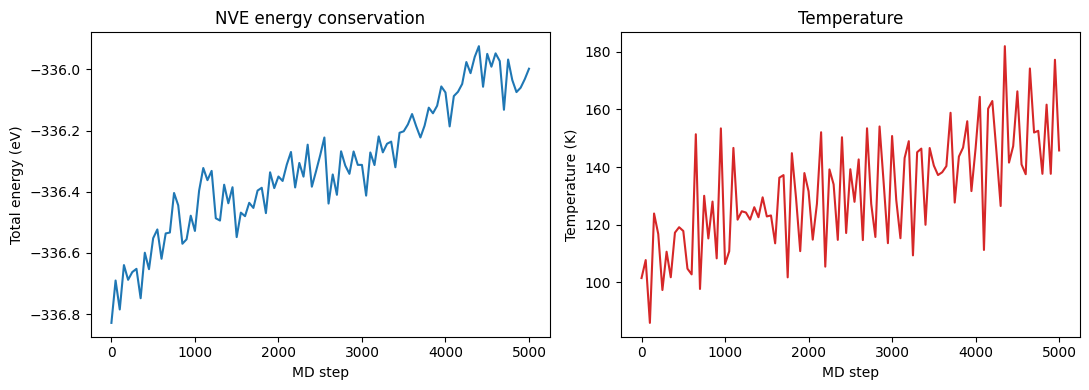

In [14]:
import matplotlib.pyplot as plt
from lammps.formats import LogFile

log = LogFile('log.lammps')
# The last run segment is the NVE production run.
run = log.runs[-1]
step = run['Step']
etot = run['TotEng']
temp = run['Temp']
from ase.io import read as _read
natoms = len(_read('si.data', format='lammps-data', style='atomic'))

drift = (max(etot) - min(etot)) / natoms * 1000  # meV/atom over the run
print(f'Total-energy range over NVE run: {drift:.2f} meV/atom')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(step, etot)
ax[0].set_xlabel('MD step'); ax[0].set_ylabel('Total energy (eV)')
ax[0].set_title('NVE energy conservation')
ax[1].plot(step, temp, color='tab:red')
ax[1].set_xlabel('MD step'); ax[1].set_ylabel('Temperature (K)')
ax[1].set_title('Temperature')
plt.tight_layout(); plt.show()

## 6. (Optional) Melt–quench to make amorphous Si

`melt_quench_si.in` heats Si to 3500 K, holds it molten, then quenches back to 300 K — producing amorphous Si
in `si_quenched.data`, with the full trajectory in `si_melt_quench.lammpstrj`.

This is longer (~9 ps); on CPU it can take several minutes.

In [15]:
import os
LMP = os.path.expanduser('~/lammps-alignn/build/lmp')
!{LMP} -in melt_quench_si.in

LAMMPS (29 Aug 2024 - Update 1)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
Reading data file ...
  orthogonal box = (0 0 0) to (10.804025 10.803281 10.803721)
  1 by 1 by 1 MPI processor grid
  reading atoms ...
  64 atoms
  read_data CPU = 0.001 seconds

CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE

Your simulation uses code contributions which should be cited:
- Type Label Framework: https://doi.org/10.1021/acs.jpcb.3c08419
The log file lists these citations in BibTeX format.

CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE

Neighbor list info ...
  update: every = 1 steps, delay = 0 steps, check = yes
  max neighbors/atom: 2000, page size: 100000
  master list distance cutoff = 7
  ghost atom cutoff = 7
  binsize = 3.5, bins = 4 4 4
  1 neighbor lists, perpetual/occasional/extra = 1 0 0
  (1) pair alignn, perpetual
      attributes: full, newton on, ghost
      pair bu

/tmp/ipykernel_34062/183632999.py:12: FutureWarning: Use `ase.geometry.rdf.get_rdf` instead.
  rdf, r = Analysis(atoms).get_rdf(rmax=rmax, nbins=nbins, return_dists=True)[0]


CellTooSmall: The cell is not large enough in direction 0: 10.804 < 2*rmax= 12.000. Recommended rmax = 5.0

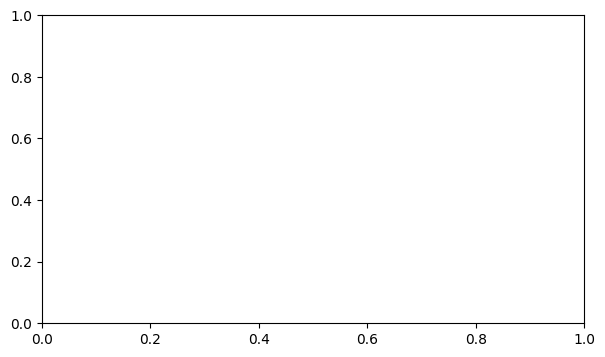

In [17]:
# Compare the radial distribution function of crystalline vs amorphous Si.
from ase.io import read
from ase.geometry.analysis import Analysis
import matplotlib.pyplot as plt

crystal = read('si.data', format='lammps-data', style='atomic')
amorph  = read('si_quenched.data', format='lammps-data', style='atomic')

rmax, nbins = 6.0, 120
fig, ax = plt.subplots(figsize=(7, 4))
for atoms, label in [(crystal, 'crystalline (start)'), (amorph, 'amorphous (quenched)')]:
    rdf, r = Analysis(atoms).get_rdf(rmax=rmax, nbins=nbins, return_dists=True)[0]
    ax.plot(r, rdf, label=label)
ax.set_xlabel('r (Å)'); ax.set_ylabel('g(r)')
ax.set_title('Si radial distribution function'); ax.legend()
plt.tight_layout(); plt.show()

## Next steps & notes

- **Other systems:** `build_sio2.py` + `melt_quench_sio2.in` run the same workflow for α-quartz SiO₂. For your
  own structure, write a `lammps-data` file with `ase.io.write(..., format='lammps-data', specorder=[...])`
  and list the element symbols (in type order) on the `pair_coeff` line.
- **Match cutoff/max_neighbors to the model.** Always read them from the model's `config.json`
  (top-level keys), not guessed.
- **Energy conservation:** the stock `mps` checkpoint is a smoke-test model (stress was not fit). For
  MLIP-grade NVE conservation, use a model trained with a smooth radial cutoff envelope.
- **No-LAMMPS alternative:** for quick relaxations / MD without compiling LAMMPS, use the ASE interface
  directly — `from alignn.ff.ff import ForceField, default_path`.

**Links**
- ALIGNN repo: https://github.com/atomgptlab/alignn
- LAMMPS examples (sources for this notebook): `alignn/examples/lammps/`
- Build script: `alignn/scripts/torch/build_lammps_alignn.sh`
- C++ pair style: `alignn/scripts/torch/pair_alignn/`